# 04 Water Quality Context

**Series:** Tribal Water Monitoring  
**Author:** Lilly Jones, PhD, Daear Consulting, LLC                             
**Primary Focus:** Pine Ridge (Oglala Lakota), Rosebud (Sicangu Lakota)  
**Collective:** Oceti Sakowin  
**Data Sources:** USGS/EPA Water Quality Portal (public), Tribal sampling data (if available)

## Water Quality on Oceti Sakowin Lands
Drinking water quality on Pine Ridge and Rosebud reflects both natural
geochemistry and the legacy of infrastructure underinvestment. Key concerns:

- **Naturally occurring mineralization** the Arikaree and Ogallala
  aquifers in this region can carry elevated TDS (total dissolved solids),
  sulfate, and fluoride from the geologic formations
- **Nitrate** from agricultural activity in upgradient areas and from
  septic systems in communities without central wastewater infrastructure
- **Variable quality by source** spring, well, and surface water sources
  show wide variation; some sources are marginal or impaired

## Data Approach
Public water quality data from the USGS/EPA Water Quality Portal is sparse
for the study area, the same monitoring infrastructure gap documented in
notebooks 01 and 02. Where Tribal sampling data is available in `data/raw/`,
this notebook shows both side by side.

## Research Questions
- Which parameters exceed EPA MCLs in the public record?
- What does the spatial distribution of exceedances look like?
- Where are the data gaps that Tribal sampling programs fill?
- What do Tribal-collected samples show that the public record cannot?

In [26]:
# Imports
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
from datetime import datetime
import requests
from io import StringIO

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx
import yaml

from src.constants import (
    CRS_GEOGRAPHIC, CRS_PROJECTED,
    OCETI_SAKOWIN_BBOX, PINE_RIDGE_BBOX, ROSEBUD_BBOX,
    PRIMARY_NATIONS, OUTPUTS_DIR, FIGURES_DIR,
    REPO_ROOT as _REPO_ROOT,
)
from src.loaders import (
    load_tribal_boundaries,
    load_water_quality,
    load_tribal_water_quality,
)
from src.indicators import flag_water_quality_exceedances
from src.sovereignty import print_data_acknowledgment, generate_citations

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
%matplotlib inline

def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

with open(_REPO_ROOT / "config" / "config.yaml") as f:
    CONFIG = yaml.safe_load(f)

WQ_THRESHOLDS = CONFIG["thresholds"]["water_quality"]
START_YEAR    = CONFIG["analysis"]["start_year"]

print("Water quality thresholds (EPA MCLs):")
for k, v in WQ_THRESHOLDS.items():
    print(f"  {k}: {v}")

Water quality thresholds (EPA MCLs):
  nitrate_mgl: 10.0
  arsenic_ugl: 10.0
  tds_mgl: 500.0
  ph_min: 6.5
  ph_max: 8.5
  turbidity_ntu: 1.0
  fluoride_mgl: 4.0


In [27]:
# Print data sovereignty notice at the top of every notebook 
print_data_acknowledgment(
    source_keys=["usgs_nwis_water_quality", "tribal_water_quality", "census_aiannh"]
)


TRIBAL WATER MONITORING DATA GOVERNANCE ACKNOWLEDGMENT

This analysis uses data that describes the lands, waters, and communities
of the Oceti Sakowin (the seven council fires of the Lakota, Dakota, and
Nakota peoples). This data is governed by the following frameworks:

OCAP®  : The Oceti Sakowin and all Tribal Nations have the right to
  Ownership, Control, Access, and Possession of data about their lands
  and communities. Federal monitoring data covering Tribal territories
  does not transfer that authority to federal agencies or researchers.
  Reference: https://fnigc.ca/ocap-training/

CARE   : Data use must deliver Collective Benefit to Indigenous peoples,
  respect their Authority to Control, uphold Responsibility to communities,
  and center Ethics across the full data lifecycle.
  Reference: https://www.gida-global.org/care

FAIR   : Data is Findable, Accessible, Interoperable, and Reusable.
  FAIR governs technical standards; CARE and OCAP® govern the ethical
  obligations 

## Load Boundaries

In [28]:
boundaries_path = OUTPUTS_DIR/"oceti_sakowin_boundaries.geojson"
if boundaries_path.exists():
    oceti_sakowin = gpd.read_file(boundaries_path)
else:
    oceti_sakowin = load_tribal_boundaries()

primary = oceti_sakowin[oceti_sakowin["common_name"].isin(PRIMARY_NATIONS)]
print(f"Nations: {len(oceti_sakowin)} | Primary: {len(primary)}")

Nations: 8 | Primary: 2


## Load Public Water Quality Data (USGS/EPA WQP)

In [29]:
# Query WQP for key drinking water parameters
# Split into Pine Ridge and Rosebud bboxes — WQP rejects large bounding boxes
from datetime import datetime

WQ_PARAMS = [
    "Nitrate",
    "pH",
    "Total dissolved solids",
    "Turbidity",
    "Arsenic",
    "Fluoride",
]

# WQP requires MM-dd-yyyy format
start_wqp = datetime.strptime(f"{START_YEAR}-01-01", "%Y-%m-%d").strftime("%m-%d-%Y")

wq_parts = []
for name, bbox in [("Pine Ridge", PINE_RIDGE_BBOX), ("Rosebud", ROSEBUD_BBOX)]:
    print(f"Querying WQP for {name}...")
    df = load_water_quality(
        bbox            = bbox,
        start_date      = f"{START_YEAR}-01-01",
        characteristics = WQ_PARAMS,
    )
    if not df.empty:
        df["region"] = name
        wq_parts.append(df)
        print(f"  {len(df):,} records")
    else:
        print(f"  No data returned: monitoring gap finding for {name}")

if wq_parts:
    wq_public = pd.concat(wq_parts, ignore_index=True)
    print(f"\nTotal public WQ records: {len(wq_public):,}")
    if "CharacteristicName" in wq_public.columns:
        print("\nBy parameter:")
        print(wq_public["CharacteristicName"].value_counts().to_string())
    if "ActivityStartDate" in wq_public.columns:
        dates = pd.to_datetime(wq_public["ActivityStartDate"], errors="coerce")
        print(f"\nDate range: {dates.min().date()} to {dates.max().date()}")
else:
    wq_public = pd.DataFrame()
    print("\nNo public WQP data returned for either reservation.")
    print("Sparse public WQ monitoring on Tribal lands is a federal")
    print("infrastructure equity gap, not evidence of clean water.")
    print("Tribal sampling data (data/raw/) fills this gap.")

Querying WQP for Pine Ridge...
  13,967 records
Querying WQP for Rosebud...
  8,051 records

Total public WQ records: 22,018

By parameter:
CharacteristicName
pH                        10558
Turbidity                  5352
Nitrate                    2549
Total dissolved solids     2513
Arsenic                     947
Fluoride                     99

Date range: 2000-01-12 to 2024-12-10


In [30]:
# Fetch station coordinates from WQP station service (separate from results)
def fetch_wqp_stations(bbox):
    from datetime import datetime
    r = requests.get(
        "https://www.waterqualitydata.us/data/Station/search/",
        params={
            "bBox":     f"{bbox[0]},{bbox[1]},{bbox[2]},{bbox[3]}",
            "mimeType": "csv",
        },
        timeout=120,
    )
    if r.status_code == 200 and len(r.content) > 200:
        return pd.read_csv(StringIO(r.text), dtype=str, low_memory=False)
    print(f"  Station fetch failed: {r.status_code} {r.headers.get('Warning','')}")
    return pd.DataFrame()

print("Fetching WQP station locations...")
stations_pr = fetch_wqp_stations(PINE_RIDGE_BBOX)
stations_rb = fetch_wqp_stations(ROSEBUD_BBOX)
stations    = pd.concat([stations_pr, stations_rb], ignore_index=True).drop_duplicates(
    subset=["MonitoringLocationIdentifier"]
) if not (stations_pr.empty and stations_rb.empty) else pd.DataFrame()

print(f"Unique stations: {len(stations)}")
if not stations.empty:
    lat_lon_cols = [c for c in stations.columns
                    if "lat" in c.lower() or "lon" in c.lower()]
    print(f"Coordinate columns: {lat_lon_cols}")

Fetching WQP station locations...
Unique stations: 9002
Coordinate columns: ['LatitudeMeasure', 'LongitudeMeasure']


In [31]:
# Pivot public WQ data to wide format for threshold comparison
# One row per sample, one column per parameter

if not wq_public.empty:
    # Map WQP characteristic names to our standard column names
    CHAR_MAP = {
        "Nitrate":                  "nitrate_mgl",
        "pH":                       "ph",
        "Total dissolved solids":   "tds_mgl",
        "Turbidity":                "turbidity_ntu",
        "Arsenic":                  "arsenic_ugl",
        "Fluoride":                 "fluoride_mgl",
    }

    wq_wide_parts = []
    for char, col_name in CHAR_MAP.items():
        subset = wq_public[
            wq_public.get("CharacteristicName", pd.Series()).str.lower()
            == char.lower()
        ].copy() if "CharacteristicName" in wq_public.columns else pd.DataFrame()

        if subset.empty:
            continue

        cols = {"ActivityStartDate": "date", "result_value": col_name}
        for extra in ["MonitoringLocationIdentifier", "LatitudeMeasure",
                      "LongitudeMeasure"]:
            if extra in subset.columns:
                cols[extra] = extra

        sub = subset[list(cols.keys())].rename(columns=cols)
        wq_wide_parts.append(sub)

    if wq_wide_parts:
        from functools import reduce
        wq_wide = reduce(
            lambda a, b: pd.merge(a, b, on=["date", "MonitoringLocationIdentifier"],
                                  how="outer"),
            wq_wide_parts
        )
        print(f"Wide-format WQ table: {len(wq_wide)} samples, "
              f"{len(wq_wide.columns)} columns")
    else:
        wq_wide = pd.DataFrame()
        print("Could not pivot WQ data, structure may differ from expected.")
else:
    wq_wide = pd.DataFrame()

Wide-format WQ table: 43117 samples, 8 columns


## Load Tribal-Collected Water Quality Data

In [32]:
tribal_wq = load_tribal_water_quality()

if tribal_wq.empty:
    print("No Tribal water quality data loaded.")
    print()
    print("To add sampling results:")
    print("  1. Copy data/templates/water_quality_template.xlsx")
    print("  2. Fill in site_id, date, and parameter columns")
    print("  3. Save as data/raw/water_quality.xlsx")
    print("  4. Re-run this notebook")
else:
    print(f"Tribal WQ records: {len(tribal_wq):,}")
    print(f"Sites: {tribal_wq['site_id'].nunique()}")
    print(tribal_wq.head(4).to_string(index=False))

No Tribal water quality data loaded.

To add sampling results:
  1. Copy data/templates/water_quality_template.xlsx
  2. Fill in site_id, date, and parameter columns
  3. Save as data/raw/water_quality.xlsx
  4. Re-run this notebook


## Threshold Exceedance Analysis

In [33]:
# Apply threshold flags to whichever datasets are available
thresholds = {
    "nitrate_mgl":    WQ_THRESHOLDS.get("nitrate_mgl", 10.0),
    "arsenic_ugl":    WQ_THRESHOLDS.get("arsenic_ugl", 10.0),
    "tds_mgl":        WQ_THRESHOLDS.get("tds_mgl", 500.0),
    "ph":             None,
    "turbidity_ntu":  WQ_THRESHOLDS.get("turbidity_ntu", 1.0),
    "fluoride_mgl":   WQ_THRESHOLDS.get("fluoride_mgl", 4.0),
}

# Public data
if not wq_wide.empty:
    wq_wide_flagged = flag_water_quality_exceedances(wq_wide, thresholds)
    alert_cols  = [c for c in wq_wide_flagged.columns if c.endswith("_alert")]
    print("PUBLIC WQ EXCEEDANCES (EPA thresholds)")
    for col in alert_cols:
        param = col.replace("_alert", "")
        n     = wq_wide_flagged[col].sum()
        total = wq_wide_flagged[col].notna().sum()
        if total > 0:
            print(f"  {param}: {n}/{total} samples exceeded threshold "
                  f"({n/total*100:.1f}%)")
    if "any_alert" in wq_wide_flagged.columns:
        any_exc = wq_wide_flagged["any_alert"].sum()
        print(f"\n  Samples with ANY exceedance: {any_exc}/{len(wq_wide_flagged)}")
else:
    wq_wide_flagged = pd.DataFrame()
    print("No public WQ data available for threshold analysis.")

# Tribal data
if not tribal_wq.empty:
    tribal_wq_flagged = flag_water_quality_exceedances(tribal_wq, thresholds)
    print("\nTRIBAL WQ EXCEEDANCES (EPA thresholds)")
    print("=" * 50)
    for col in [c for c in tribal_wq_flagged.columns if c.endswith("_alert")]:
        param = col.replace("_alert", "")
        n     = tribal_wq_flagged[col].sum()
        total = tribal_wq_flagged[col].notna().sum()
        if total > 0:
            print(f"  {param}: {n}/{total} samples exceeded threshold "
                  f"({n/total*100:.1f}%)")
else:
    tribal_wq_flagged = pd.DataFrame()

PUBLIC WQ EXCEEDANCES (EPA thresholds)
  nitrate_mgl: 15/43117 samples exceeded threshold (0.0%)
  arsenic_ugl: 106/43117 samples exceeded threshold (0.2%)
  tds_mgl: 6411/43117 samples exceeded threshold (14.9%)
  ph: 5873/43117 samples exceeded threshold (13.6%)
  turbidity_ntu: 17013/43117 samples exceeded threshold (39.5%)
  fluoride_mgl: 0/43117 samples exceeded threshold (0.0%)
  any: 25258/43117 samples exceeded threshold (58.6%)

  Samples with ANY exceedance: 25258/43117


## Visualizations

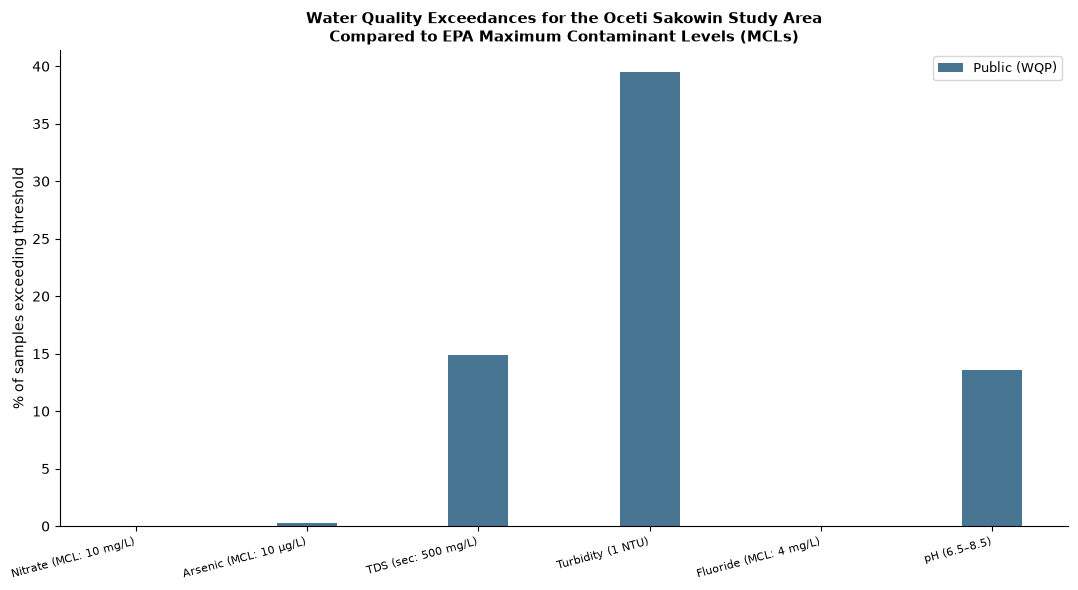

In [34]:
# Exceedance summary bar chart
datasets = []
if not wq_wide_flagged.empty:
    datasets.append(("Public (WQP)", wq_wide_flagged, "#1A5276"))
if not tribal_wq_flagged.empty:
    datasets.append(("Tribal sampling", tribal_wq_flagged, "#C0392B"))

params = ["nitrate_mgl", "arsenic_ugl", "tds_mgl",
          "turbidity_ntu", "fluoride_mgl", "ph"]
param_labels = ["Nitrate (MCL: 10 mg/L)", "Arsenic (MCL: 10 µg/L)",
                "TDS (sec: 500 mg/L)", "Turbidity (1 NTU)",
                "Fluoride (MCL: 4 mg/L)", "pH (6.5–8.5)"]

if datasets:
    fig, ax = plt.subplots(figsize=(11, 6))
    width   = 0.35
    x       = np.arange(len(params))

    for i, (label, df, color) in enumerate(datasets):
        pcts = []
        for p in params:
            col = f"{p}_alert"
            if col in df.columns:
                total = df[col].notna().sum()
                pct   = df[col].sum() / total * 100 if total > 0 else 0
            else:
                pct = 0
            pcts.append(pct)
        offset = width * (i - len(datasets) / 2 + 0.5)
        ax.bar(x + offset, pcts, width, color=color, alpha=0.8, label=label)

    ax.set_xticks(x)
    ax.set_xticklabels(param_labels, rotation=15, ha="right", fontsize=8)
    ax.set_ylabel("% of samples exceeding threshold", fontsize=10)
    ax.set_title(
        "Water Quality Exceedances for the Oceti Sakowin Study Area\n"
        "Compared to EPA Maximum Contaminant Levels (MCLs)",
        fontsize=11, fontweight="bold",
    )
    ax.legend(fontsize=9)
    despine(ax)
    plt.tight_layout()
    try:
        fig.savefig(FIGURES_DIR/"04_wq_exceedances.png",
                    dpi=150, bbox_inches="tight")
    except Exception:
        pass
    plt.show()
else:
    print("No water quality data available for visualization.")
    print()
    print("FINDING: Absence of public WQ monitoring data in this area")
    print("is itself a significant equity finding. The Water Quality Portal")
    print("has very limited coverage on Oceti Sakowin lands. Tribal sampling")
    print("programs provide the only systematic record of drinking water quality.")

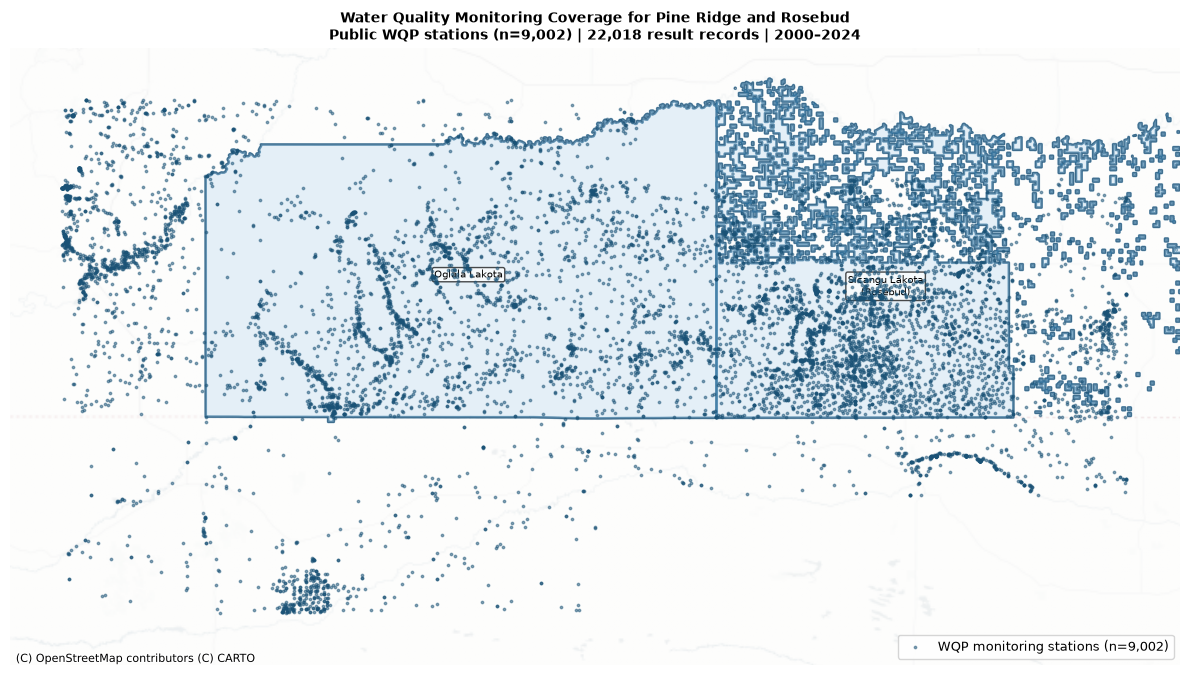

Mapped 9,002 stations across Pine Ridge and Rosebud study areas


In [35]:
# Plot WQ site locations 

fig, ax = plt.subplots(figsize=(12, 8))

oceti_sakowin.to_crs(3857).plot(
    ax=ax, facecolor="#F4F6F7", edgecolor="#566573",
    linewidth=1.5, zorder=1,
)
primary.to_crs(3857).plot(
    ax=ax, facecolor="#D6EAF8", edgecolor="#2471A3",
    linewidth=2, zorder=2, alpha=0.5,
)

for _, nation in primary.iterrows():
    c = nation.geometry.centroid
    c3857 = gpd.GeoSeries([c], crs=CRS_GEOGRAPHIC).to_crs(3857).iloc[0]
    ax.annotate(
        nation["common_name"].replace(" (", "\n("),
        (c3857.x, c3857.y), ha="center", fontsize=7,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7),
    )

if not stations.empty:
    stations["LatitudeMeasure"]  = pd.to_numeric(stations["LatitudeMeasure"],  errors="coerce")
    stations["LongitudeMeasure"] = pd.to_numeric(stations["LongitudeMeasure"], errors="coerce")
    stations_clean = stations.dropna(subset=["LatitudeMeasure", "LongitudeMeasure"])

    # Filter to Pine Ridge and Rosebud bboxes only
    in_pr = (
        (stations_clean["LongitudeMeasure"] >= PINE_RIDGE_BBOX[0]) &
        (stations_clean["LongitudeMeasure"] <= PINE_RIDGE_BBOX[2]) &
        (stations_clean["LatitudeMeasure"]  >= PINE_RIDGE_BBOX[1]) &
        (stations_clean["LatitudeMeasure"]  <= PINE_RIDGE_BBOX[3])
    )
    in_rb = (
        (stations_clean["LongitudeMeasure"] >= ROSEBUD_BBOX[0]) &
        (stations_clean["LongitudeMeasure"] <= ROSEBUD_BBOX[2]) &
        (stations_clean["LatitudeMeasure"]  >= ROSEBUD_BBOX[1]) &
        (stations_clean["LatitudeMeasure"]  <= ROSEBUD_BBOX[3])
    )
    stations_clean = stations_clean[in_pr | in_rb].copy()

    wq_gdf = gpd.GeoDataFrame(
        stations_clean,
    )

    wq_gdf = gpd.GeoDataFrame(
        stations_clean,
        geometry=gpd.points_from_xy(
            stations_clean["LongitudeMeasure"],
            stations_clean["LatitudeMeasure"],
        ),
        crs=CRS_GEOGRAPHIC,
    )
    wq_gdf.to_crs(3857).plot(
        ax=ax, color="#1A5276", marker="o", markersize=3,
        alpha=0.5, zorder=3,
        label=f"WQP monitoring stations (n={len(wq_gdf):,})",
    )
# Clip map extent to Pine Ridge and Rosebud combined bbox
    combined_bbox = (
        min(PINE_RIDGE_BBOX[0], ROSEBUD_BBOX[0]),  # west
        min(PINE_RIDGE_BBOX[1], ROSEBUD_BBOX[1]),  # south
        max(PINE_RIDGE_BBOX[2], ROSEBUD_BBOX[2]),  # east
        max(PINE_RIDGE_BBOX[3], ROSEBUD_BBOX[3]),  # north
    )
    # Convert bbox corners to Web Mercator for ax.set_xlim/ylim
    bbox_gdf = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy(
            [combined_bbox[0], combined_bbox[2]],
            [combined_bbox[1], combined_bbox[3]],
        ),
        crs=CRS_GEOGRAPHIC,
    ).to_crs(3857)
    xs = bbox_gdf.geometry.x.values
    ys = bbox_gdf.geometry.y.values
    margin = 20_000   # 20 km margin in meters
    ax.set_xlim(xs[0] - margin, xs[1] + margin)
    ax.set_ylim(ys[0] - margin, ys[1] + margin)
try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.4)
except Exception:
    pass

ax.set_axis_off()
ax.legend(fontsize=9, loc="lower right")
ax.set_title(
    "Water Quality Monitoring Coverage for Pine Ridge and Rosebud\n"
    f"Public WQP stations (n={len(wq_gdf):,}) | "
    f"22,018 result records | 2000–2024",
    fontsize=10, fontweight="bold",
)
plt.tight_layout()
try:
    fig.savefig(FIGURES_DIR/"04_wq_monitoring_coverage.png",
                dpi=150, bbox_inches="tight")
except Exception:
    pass
plt.show()

print(f"Mapped {len(wq_gdf):,} stations across Pine Ridge and Rosebud study areas")

## Exports

In [36]:
if not wq_wide_flagged.empty:
    wq_wide_flagged.to_csv(OUTPUTS_DIR/"wq_public_flagged.csv", index=False)
    print("Exported to outputs/wq_public_flagged.csv")

# Tribal WQ data: export ALERT flags only: never export raw values externally
# Raw Tribal WQ data stays in data/raw/ under Tribal governance
if not tribal_wq_flagged.empty:
    alert_export = tribal_wq_flagged[
        ["site_id", "date", "any_alert"]
        + [c for c in tribal_wq_flagged.columns if c.endswith("_alert")]
    ]
    alert_export.to_csv(OUTPUTS_DIR/"wq_tribal_alerts.csv", index=False)
    print("Exported to outputs/wq_tribal_alerts.csv")
    print("  (Alert flags only: raw Tribal WQ values remain in data/raw/)")

Exported to outputs/wq_public_flagged.csv


## Summary and Findings

*(Fill in after running.)*

**Public Monitoring Gap:**  
Quantify how many WQP samples exist for the study area. If zero or very
few, state explicitly: the absence of public water quality monitoring
data on Oceti Sakowin lands is a systemic equity finding. Tribal water
quality programs are not supplementing federal monitoring, they are
providing the only monitoring that exists.

**Exceedances (if data available):**  
Which parameters exceed EPA MCLs? What percentage of samples? Are
exceedances concentrated at specific site types (well vs. spring
vs. surface)?

**Natural vs. Anthropogenic:**  
Elevated TDS, sulfate, and fluoride in Arikaree aquifer water are
largely geogenic; from the geologic formation, not contamination.
Nitrate and arsenic exceedances are more likely anthropogenic (agriculture, septic).
Distinguishing these has management implications.

**Connection to the rest of the series:**  
Water quality alert flags from this notebook feed into the Compound
Water Stress Index in notebook 06. The operational pipeline
(`pipeline/water_quality.py`) automates these threshold checks
for ongoing monitoring.

In [37]:
print(generate_citations(["usgs_nwis_water_quality", "tribal_water_quality"]))

DATA CITATIONS

USGS/EPA Water Quality Portal
  https://www.waterqualitydata.us/
  Steward: USGS / EPA | License: Public domain

Tribal-collected water quality data
  Steward: Tribal Nation Water Resources Program | License: Tribal governance: CARE applies

Data governance: OCAP® | CARE | FAIR | IEEE 2890-2025
  OCAP: https://fnigc.ca/ocap-training/
  CARE: https://www.gida-global.org/care
  FAIR: https://www.go-fair.org/fair-principles/
  IEEE_2890: https://standards.ieee.org/ieee/2890/10318/
  LOCAL_CONTEXTS: https://localcontexts.org/
